# Load Dependencies

In [22]:
import csv, json, pandas as pd, matplotlib.pyplot as plt, numpy as np, statsmodels.formula.api as smf, statsmodels.api as sm

 # Load in the data and EDA

In [23]:
df = pd.read_csv('college_major_roi.csv')
print(df.head(10))

   grad_id                   major  major_category institution_tier  \
0  G000000                 biology            STEM         mid_tier   
1  G000001               marketing        business         mid_tier   
2  G000002  electrical_engineering            STEM       top_public   
3  G000003               marketing        business       top_public   
4  G000004               marketing        business        ivy_elite   
5  G000005                business        business         regional   
6  G000006               economics        business         regional   
7  G000007             social_work  social_science         mid_tier   
8  G000008  mechanical_engineering            STEM         regional   
9  G000009                 finance        business       top_public   

   institution_selectivity_pctile   gpa  had_internship  completed_on_time  \
0                              52  2.58               0                  0   
1                              61  2.58               0       

In [24]:
print(df.describe())

       institution_selectivity_pctile           gpa  had_internship  \
count                    30000.000000  30000.000000    30000.000000   
mean                        55.086067      3.093337        0.436067   
std                         18.593708      0.439060        0.495904   
min                         16.000000      1.500000        0.000000   
25%                         42.000000      2.790000        0.000000   
50%                         55.000000      3.100000        0.000000   
75%                         68.000000      3.400000        1.000000   
max                        102.000000      4.000000        1.000000   

       completed_on_time   net_cost_usd       debt_usd  hs_baseline_10yr_usd  \
count       30000.000000   30000.000000   30000.000000          30000.000000   
mean            0.682367   88621.496667   38498.063333         359893.416667   
std             0.465564   33576.903160   37801.748200          39923.943255   
min             0.000000   28500.000000 

In [25]:
# check column data types
print(df.dtypes)

grad_id                            object
major                              object
major_category                     object
institution_tier                   object
institution_selectivity_pctile      int64
gpa                               float64
had_internship                      int64
completed_on_time                   int64
region                             object
net_cost_usd                        int64
debt_usd                            int64
hs_baseline_10yr_usd                int64
added_earnings_10yr_usd             int64
earnings_10yr_usd                   int64
net_roi_usd                         int64
roi_pct                           float64
positive_roi                        int64
high_roi                            int64
dtype: object


In [26]:
# find the unique value of interesed columns
print(df['major'].unique())
print(df['major_category'].unique())
print(df['institution_tier'].unique())

['biology' 'marketing' 'electrical_engineering' 'business' 'economics'
 'social_work' 'mechanical_engineering' 'finance' 'computer_engineering'
 'education' 'chemical_engineering' 'communications' 'computer_science'
 'nursing' 'criminal_justice' 'fine_arts' 'humanities' 'psychology'
 'business_analytics']
['STEM' 'business' 'social_science' 'education' 'health' 'arts'
 'humanities']
['mid_tier' 'top_public' 'ivy_elite' 'regional' 'for_profit']


## QA of the data

In [27]:
# Null count and percentage per column
null_summary = pd.DataFrame({
    "null_count": df.isnull().sum(),
    "null_pct": (df.isnull().mean() * 100).round(2),
        })

print(null_summary)

                                null_count  null_pct
grad_id                                  0       0.0
major                                    0       0.0
major_category                           0       0.0
institution_tier                         0       0.0
institution_selectivity_pctile           0       0.0
gpa                                      0       0.0
had_internship                           0       0.0
completed_on_time                        0       0.0
region                                   0       0.0
net_cost_usd                             0       0.0
debt_usd                                 0       0.0
hs_baseline_10yr_usd                     0       0.0
added_earnings_10yr_usd                  0       0.0
earnings_10yr_usd                        0       0.0
net_roi_usd                              0       0.0
roi_pct                                  0       0.0
positive_roi                             0       0.0
high_roi                                 0    

In [28]:
# check for null or NaN varietiants
df = pd.read_csv("college_major_roi.csv", na_values=["N/A", "NA", "?", "-", ""])
print(df.head())

   grad_id                   major major_category institution_tier  \
0  G000000                 biology           STEM         mid_tier   
1  G000001               marketing       business         mid_tier   
2  G000002  electrical_engineering           STEM       top_public   
3  G000003               marketing       business       top_public   
4  G000004               marketing       business        ivy_elite   

   institution_selectivity_pctile   gpa  had_internship  completed_on_time  \
0                              52  2.58               0                  0   
1                              61  2.58               0                  1   
2                              78  3.14               1                  1   
3                              77  3.04               0                  1   
4                             100  3.81               0                  0   

      region  net_cost_usd  debt_usd  hs_baseline_10yr_usd  \
0      south        144400         0            

# Question to Answer
Does the institution you go to make you earn more than the major you pick?

In [29]:
print(df.columns)

Index(['grad_id', 'major', 'major_category', 'institution_tier',
       'institution_selectivity_pctile', 'gpa', 'had_internship',
       'completed_on_time', 'region', 'net_cost_usd', 'debt_usd',
       'hs_baseline_10yr_usd', 'added_earnings_10yr_usd', 'earnings_10yr_usd',
       'net_roi_usd', 'roi_pct', 'positive_roi', 'high_roi'],
      dtype='object')


In [30]:
# new df for analysis
# Subset of columns for the analysis

cols = [
    "major", "major_category", "institution_tier", "region",
    "net_cost_usd", "hs_baseline_10yr_usd",
    "added_earnings_10yr_usd", "earnings_10yr_usd",
]

roi_df = df[cols].copy()

print(roi_df.shape)

roi_df.head()

(30000, 8)


,major,major_category,institution_tier,region,net_cost_usd,hs_baseline_10yr_usd,added_earnings_10yr_usd,earnings_10yr_usd
0,biology,STEM,mid_tier,south,144400,411700,101000,512700
1,marketing,business,mid_tier,northeast,57400,356900,330600,687500
2,electrical_engineering,STEM,top_public,northeast,65100,339600,655100,994700
3,marketing,business,top_public,midwest,105800,399600,197500,597100
4,marketing,business,ivy_elite,south,219200,335700,222900,558600


In [31]:
# comparing the earnings from college

outcome = "added_earnings_10yr_usd"

def summarize(group_col):
    return (
        roi_df.groupby(group_col)[outcome]
        .agg(n="count", mean="mean", median="median", std="std")
        .round(0)
        .sort_values("median", ascending=False)
    )

by_tier = summarize("institution_tier")
by_major = summarize("major")
by_category = summarize("major_category")

print("By institution tier:\n", by_tier, "\n")
print("By major category:\n", by_category, "\n")
print("By major:\n", by_major)

By institution tier:
                       n      mean    median       std
institution_tier                                     
ivy_elite          1752  542429.0  475200.0  423604.0
top_public         5996  422451.0  351100.0  336520.0
mid_tier          10258  362820.0  301850.0  286123.0
regional           9060  309755.0  261300.0  241400.0
for_profit         2934  222465.0  190600.0  172296.0 

By major category:
                    n      mean    median       std
major_category                                    
STEM            9904  535558.0  479000.0  306136.0
health          1589  440662.0  403700.0  202209.0
business        8361  434319.0  376900.0  253581.0
social_science  5989  120088.0  106000.0   63909.0
education       1352  100184.0   89950.0   46451.0
humanities      1410   75717.0   68550.0   35761.0
arts            1395   48115.0   42800.0   23328.0 

By major:
                            n      mean    median       std
major                                          

In [32]:
# confirming suspicions about the added earnings by institution tier

def median_range(summary):
    return summary["median"].max() - summary["median"].min()

print(f"Range of median added earnings across tiers:  ${median_range(by_tier):,.0f}")
print(f"Range of median added earnings across majors: ${median_range(by_major):,.0f}")

Range of median added earnings across tiers:  $284,600
Range of median added earnings across majors: $569,500


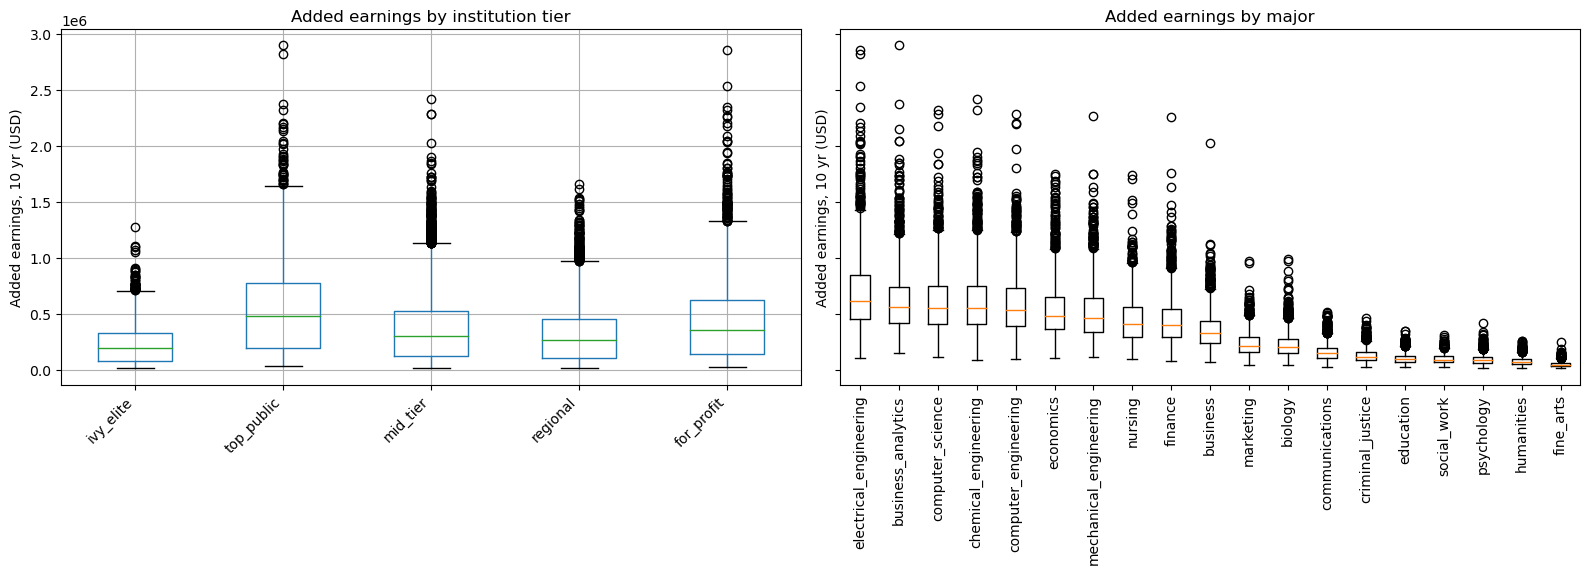

In [33]:
# visualizing data

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Tier ordered by median
tier_order = by_tier.index.tolist()
roi_df.boxplot(column=outcome, by="institution_tier", ax=axes[0],
               positions=range(len(tier_order)))
axes[0].set_xticklabels(tier_order, rotation=45, ha="right")
axes[0].set_title("Added earnings by institution tier")

# Major ordered by median
major_order = by_major.index.tolist()
data = [roi_df.loc[roi_df["major"] == m, outcome] for m in major_order]
axes[1].boxplot(data, labels=major_order)
axes[1].set_xticklabels(major_order, rotation=90)
axes[1].set_title("Added earnings by major")

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("Added earnings, 10 yr (USD)")
plt.suptitle("")
plt.tight_layout()
plt.show()

In [34]:
print(roi_df.groupby("institution_tier")["net_cost_usd"].median().sort_values())

institution_tier
regional       62100.0
mid_tier       80300.0
top_public     88900.0
for_profit    113350.0
ivy_elite     153450.0
Name: net_cost_usd, dtype: float64


In [35]:
# majors by tier

# Share of each tier's students in each major (rows sum to 100%)
ct = pd.crosstab(roi_df["institution_tier"], roi_df["major_category"], normalize="index").round(3) * 100
print(ct)

# Raw counts, to spot thin cells
print(pd.crosstab(roi_df["major"], roi_df["institution_tier"]))

major_category    STEM  arts  business  education  health  humanities  \
institution_tier                                                        
for_profit        33.9   4.4      25.7        4.5     6.2         4.6   
ivy_elite         33.7   4.2      28.2        4.2     5.7         4.6   
mid_tier          33.3   4.8      27.7        4.4     5.2         4.9   
regional          32.5   4.5      28.3        4.7     5.2         4.6   
top_public        32.7   4.8      28.6        4.4     5.1         4.5   

major_category    social_science  
institution_tier                  
for_profit                  20.6  
ivy_elite                   19.5  
mid_tier                    19.6  
regional                    20.3  
top_public                  19.9  
institution_tier        for_profit  ivy_elite  mid_tier  regional  top_public
major                                                                        
biology                        167        109       610       500         349
business 

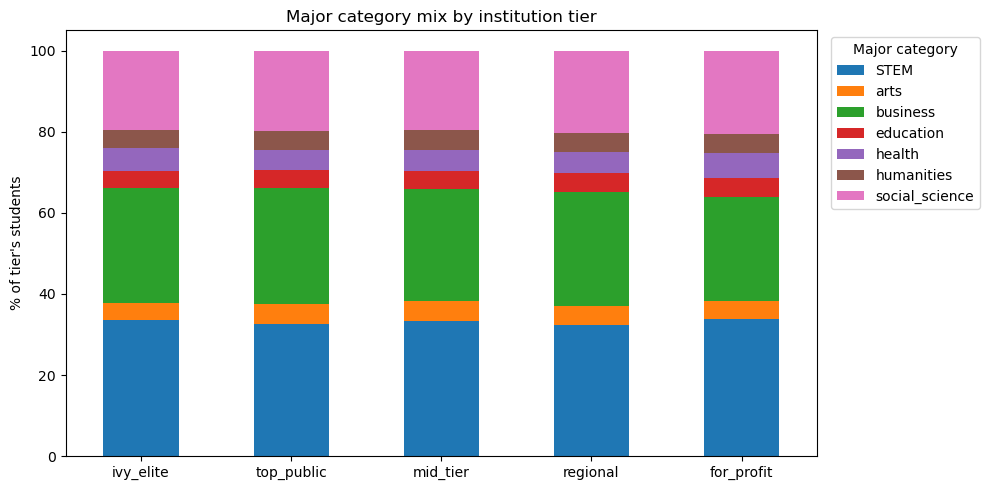

In [37]:
# VISUALIZING DATA BY INSITUTE TIER AND MAJOR CATEGORY

cat_mix = pd.crosstab(
    roi_df["institution_tier"], roi_df["major_category"], normalize="index"
) * 100
cat_mix = cat_mix.loc[tier_order]

ax = cat_mix.plot(kind="bar", stacked=True, figsize=(10, 5))
ax.set_ylabel("% of tier's students")
ax.set_xlabel("")
ax.set_title("Major category mix by institution tier")
ax.legend(title="Major category", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

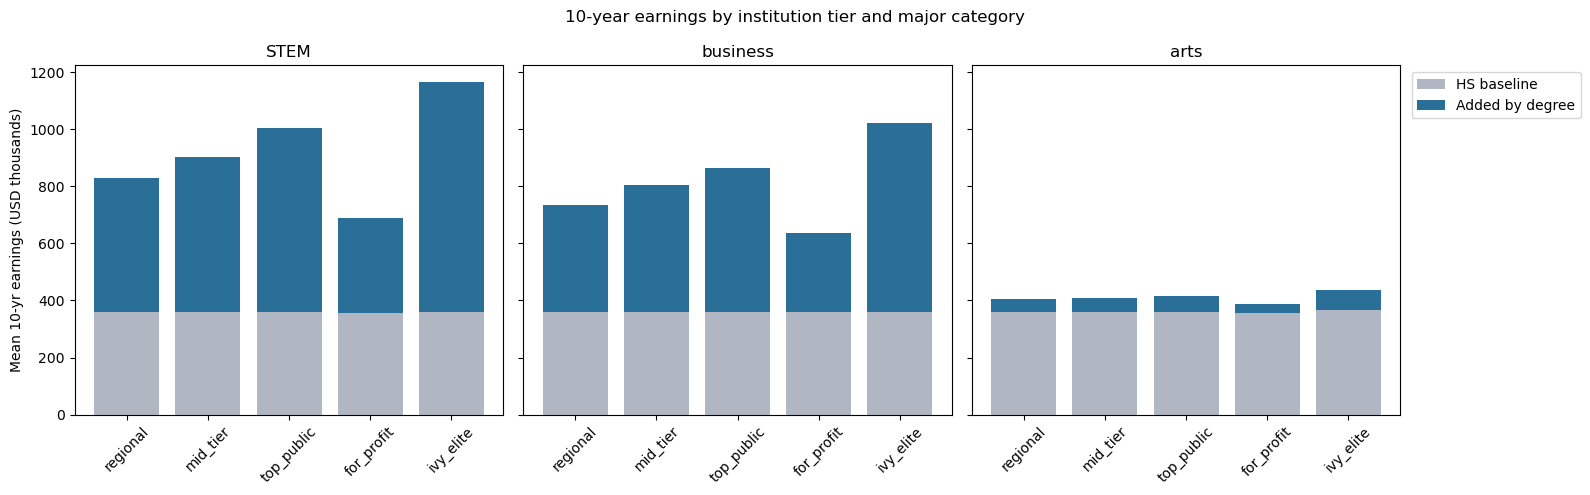

In [39]:
# visualizing by major category and tier

categories = ["STEM", "business", "arts"]  # adjust to match the names printed above
tier_order = ["regional", "mid_tier", "top_public", "for_profit", "ivy_elite"]

plot_df = roi_df[roi_df["major_category"].isin(categories)]

# Mean baseline and added earnings per category x tier
means = (
    plot_df.groupby(["major_category", "institution_tier"])
    [["hs_baseline_10yr_usd", "added_earnings_10yr_usd"]]
    .mean()
)

fig, axes = plt.subplots(1, len(categories), figsize=(16, 5), sharey=True)

for ax, cat in zip(axes, categories):
    sub = means.loc[cat].loc[tier_order]
    ax.bar(sub.index, sub["hs_baseline_10yr_usd"] / 1e3,
           label="HS baseline", color="#b0b7c3")
    ax.bar(sub.index, sub["added_earnings_10yr_usd"] / 1e3,
           bottom=sub["hs_baseline_10yr_usd"] / 1e3,
           label="Added by degree", color="#2a6f97")
    ax.set_title(cat)
    ax.tick_params(axis="x", rotation=45)

axes[0].set_ylabel("Mean 10-yr earnings (USD thousands)")
axes[-1].legend(loc="upper left", bbox_to_anchor=(1.01, 1))
plt.suptitle("10-year earnings by institution tier and major category")
plt.tight_layout()
plt.show()

In [40]:
# checking variance for between the categories

y = "added_earnings_10yr_usd"

m_major = smf.ols(f"{y} ~ C(major)", data=roi_df).fit()
m_tier  = smf.ols(f"{y} ~ C(institution_tier)", data=roi_df).fit()
m_both  = smf.ols(f"{y} ~ C(major) + C(institution_tier)", data=roi_df).fit()

summary = pd.Series({
    "R² major only":    m_major.rsquared,
    "R² tier only":     m_tier.rsquared,
    "R² major + tier":  m_both.rsquared,
    "Unique to major":  m_both.rsquared - m_tier.rsquared,
    "Unique to tier":   m_both.rsquared - m_major.rsquared,
    "Unexplained":      1 - m_both.rsquared,
}).round(3)
print(summary)

# ANOVA table with eta squared (share of total variance per factor)
anova = sm.stats.anova_lm(m_both, typ=2)
anova["eta_sq"] = anova["sum_sq"] / anova["sum_sq"].sum()
print(anova.round(4))

R² major only      0.548
R² tier only       0.061
R² major + tier    0.608
Unique to major    0.547
Unique to tier     0.060
Unexplained        0.392
dtype: float64
                           sum_sq       df          F  PR(>F)  eta_sq
C(major)             1.425644e+15     18.0  2322.8219     0.0  0.5476
C(institution_tier)  1.557412e+14      4.0  1141.8810     0.0  0.0598
Residual             1.022141e+15  29977.0        NaN     NaN  0.3926


In [41]:
# checking if tier matters by cost for a price premium

m_cost  = smf.ols(f"{y} ~ C(major) + net_cost_usd", data=roi_df).fit()
m_full  = smf.ols(f"{y} ~ C(major) + C(institution_tier) + net_cost_usd", data=roi_df).fit()

print(f"R² major only:               {m_major.rsquared:.3f}")
print(f"R² major + cost:             {m_cost.rsquared:.3f}")
print(f"R² major + tier:             {m_both.rsquared:.3f}")
print(f"R² major + tier + cost:      {m_full.rsquared:.3f}")
print(f"Tier's unique R², before cost: {m_both.rsquared - m_major.rsquared:.3f}")
print(f"Tier's unique R², after cost:  {m_full.rsquared - m_cost.rsquared:.3f}")

# Tier coefficients relative to the baseline tier, with and without cost
coefs = pd.DataFrame({
    "tier_only_model": m_both.params.filter(like="institution_tier"),
    "with_cost": m_full.params.filter(like="institution_tier"),
}).round(0)
print(coefs)
print(f"\nCost coefficient: {m_full.params['net_cost_usd']:.2f} added $ per $1 of cost")

R² major only:               0.548
R² major + cost:             0.551
R² major + tier:             0.608
R² major + tier + cost:      0.609
Tier's unique R², before cost: 0.060
Tier's unique R², after cost:  0.058
                                   tier_only_model  with_cost
C(institution_tier)[T.ivy_elite]          315529.0   334109.0
C(institution_tier)[T.mid_tier]           142494.0   127046.0
C(institution_tier)[T.regional]            89620.0    65647.0
C(institution_tier)[T.top_public]         200891.0   189582.0

Cost coefficient: -0.44 added $ per $1 of cost


In [42]:
# does tier factor in on the major?

m_inter = smf.ols(f"{y} ~ C(major) * C(institution_tier)", data=roi_df).fit()

print(f"R² additive:     {m_both.rsquared:.3f}")
print(f"R² interaction:  {m_inter.rsquared:.3f}")

# F-test: do the interaction terms add anything?
print(sm.stats.anova_lm(m_both, m_inter).round(4))

R² additive:     0.608
R² interaction:  0.632
   df_resid           ssr  df_diff       ss_diff        F  Pr(>F)
0   29977.0  1.022141e+15      0.0           NaN      NaN     NaN
1   29905.0  9.592363e+14     72.0  6.290474e+13  27.2376     0.0


In [43]:
# finding priemium split

pivot = roi_df.pivot_table(index="major_category", columns="institution_tier",
                           values=y, aggfunc="median")[tier_order]
premium = pivot.sub(pivot["for_profit"], axis=0).round(0)
print(premium)

institution_tier  regional  mid_tier  top_public  for_profit  ivy_elite
major_category                                                         
STEM                121400    185100      283650           0     440700
arts                  7100     13450       20650           0      30950
business             91000    142900      196900           0     338550
education            20950     40550       45450           0      82800
health              127000    192100      242200           0     339300
humanities           14500     27800       36250           0      59900
social_science       27750     45700       60800           0      96700


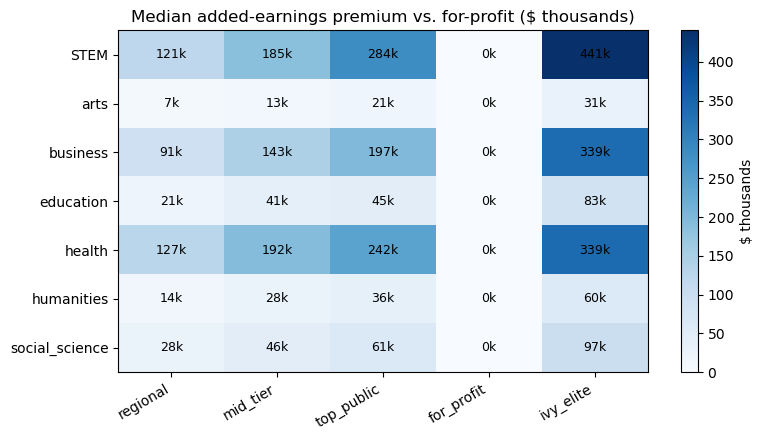

In [44]:
# making a heat map of priemium split

fig, ax = plt.subplots(figsize=(8, 4.5))
im = ax.imshow(premium / 1e3, cmap="Blues", aspect="auto")
ax.set_xticks(range(len(tier_order)), tier_order, rotation=30, ha="right")
ax.set_yticks(range(len(premium.index)), premium.index)
for i in range(premium.shape[0]):
    for j in range(premium.shape[1]):
        ax.text(j, i, f"{premium.iloc[i, j] / 1e3:.0f}k", ha="center", va="center", fontsize=9)
ax.set_title("Median added-earnings premium vs. for-profit ($ thousands)")
plt.colorbar(im, label="$ thousands")
plt.tight_layout()
plt.show()

In [45]:
# testing if tier is a multiplier or a nominal effect

roi_df["log_added"] = np.log(roi_df["added_earnings_10yr_usd"])

l_major = smf.ols("log_added ~ C(major)", data=roi_df).fit()
l_tier  = smf.ols("log_added ~ C(institution_tier)", data=roi_df).fit()
l_both  = smf.ols("log_added ~ C(major) + C(institution_tier)", data=roi_df).fit()
l_inter = smf.ols("log_added ~ C(major) * C(institution_tier)", data=roi_df).fit()

print(f"Unique to major:  {l_both.rsquared - l_tier.rsquared:.3f}")
print(f"Unique to tier:   {l_both.rsquared - l_major.rsquared:.3f}")
print(f"R² additive:      {l_both.rsquared:.3f}")
print(f"R² interaction:   {l_inter.rsquared:.3f}")
print(f"Interaction gain: {l_inter.rsquared - l_both.rsquared:.3f}")

# Residual check for the log model
resid = l_both.resid
print(resid.describe().round(3))

Unique to major:  0.768
Unique to tier:   0.047
R² additive:      0.816
R² interaction:   0.816
Interaction gain: 0.000
count    30000.000
mean        -0.000
std          0.404
min         -1.652
25%         -0.271
50%          0.001
75%          0.272
max          1.563
dtype: float64


In [46]:
# checking tier as a % booster

tier_pct = (np.exp(l_both.params.filter(like="institution_tier")) - 1) * 100
print(tier_pct.round(1).rename("% added-earnings premium vs. for_profit"))

# Same for majors, relative to the baseline major
major_pct = (np.exp(l_both.params.filter(like="C(major)")) - 1) * 100
print(major_pct.sort_values(ascending=False).round(0))

C(institution_tier)[T.ivy_elite]     138.5
C(institution_tier)[T.mid_tier]       63.6
C(institution_tier)[T.regional]       39.0
C(institution_tier)[T.top_public]     87.9
Name: % added-earnings premium vs. for_profit, dtype: float64
C(major)[T.electrical_engineering]    207.0
C(major)[T.chemical_engineering]      175.0
C(major)[T.business_analytics]        174.0
C(major)[T.computer_science]          172.0
C(major)[T.computer_engineering]      161.0
C(major)[T.economics]                 140.0
C(major)[T.mechanical_engineering]    132.0
C(major)[T.nursing]                    99.0
C(major)[T.finance]                    95.0
C(major)[T.business]                   60.0
C(major)[T.marketing]                   5.0
C(major)[T.communications]            -29.0
C(major)[T.criminal_justice]          -42.0
C(major)[T.education]                 -55.0
C(major)[T.social_work]               -57.0
C(major)[T.psychology]                -59.0
C(major)[T.humanities]                -66.0
C(major)[T.fine_ar

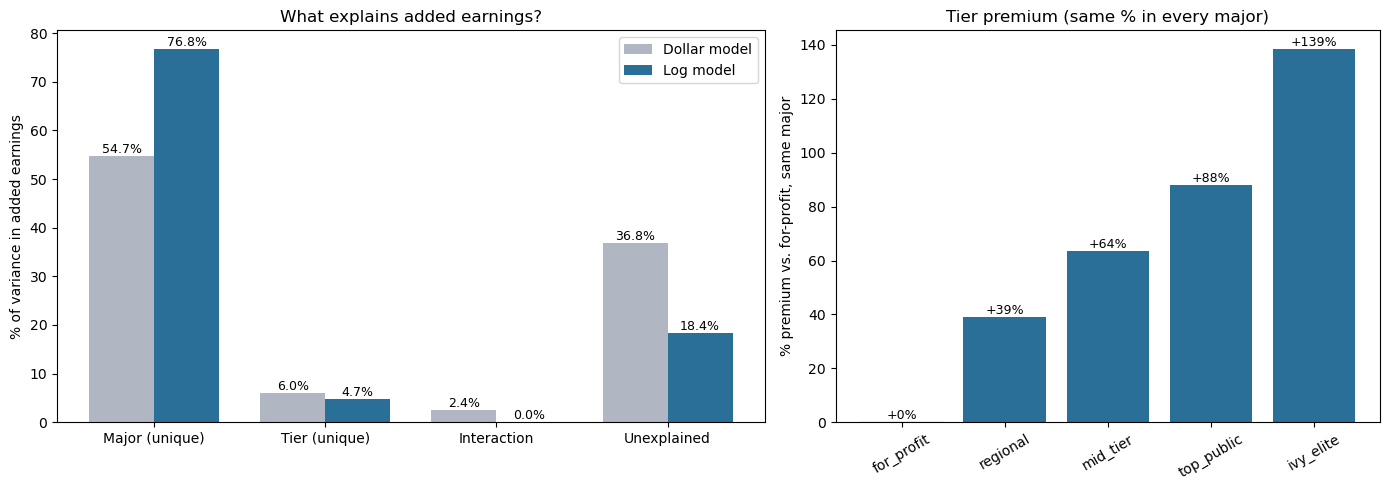

In [47]:
# --- Panel 1: variance explained, dollars vs. log ---
def shares(f_major, f_tier, f_both, f_inter):
    return {
        "Major (unique)":       f_both.rsquared - f_tier.rsquared,
        "Tier (unique)":        f_both.rsquared - f_major.rsquared,
        "Interaction":          f_inter.rsquared - f_both.rsquared,
        "Unexplained":          1 - f_inter.rsquared,
    }

dollar = shares(m_major, m_tier, m_both, m_inter)
log    = shares(l_major, l_tier, l_both, l_inter)

labels = list(dollar.keys())
x = np.arange(len(labels))
w = 0.38

fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [1.3, 1]})

ax = axes[0]
b1 = ax.bar(x - w/2, [dollar[k] * 100 for k in labels], w, label="Dollar model", color="#b0b7c3")
b2 = ax.bar(x + w/2, [log[k] * 100 for k in labels], w, label="Log model", color="#2a6f97")
ax.bar_label(b1, fmt="%.1f%%", fontsize=9)
ax.bar_label(b2, fmt="%.1f%%", fontsize=9)
ax.set_xticks(x, labels)
ax.set_ylabel("% of variance in added earnings")
ax.set_title("What explains added earnings?")
ax.legend()

# --- Panel 2: tier premium as a percentage (log model) ---
tier_order = ["for_profit", "regional", "mid_tier", "top_public", "ivy_elite"]
coefs = l_both.params.filter(like="institution_tier")
coefs.index = [i.split("T.")[1].rstrip("]") for i in coefs.index]
premium = ((np.exp(coefs) - 1) * 100).reindex(tier_order).fillna(0)  # for_profit = baseline

ax = axes[1]
bars = ax.bar(premium.index, premium.values, color="#2a6f97")
bars[0].set_color("#b0b7c3")
ax.bar_label(bars, fmt="+%.0f%%", fontsize=9)
ax.set_ylabel("% premium vs. for-profit, same major")
ax.set_title("Tier premium (same % in every major)")
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

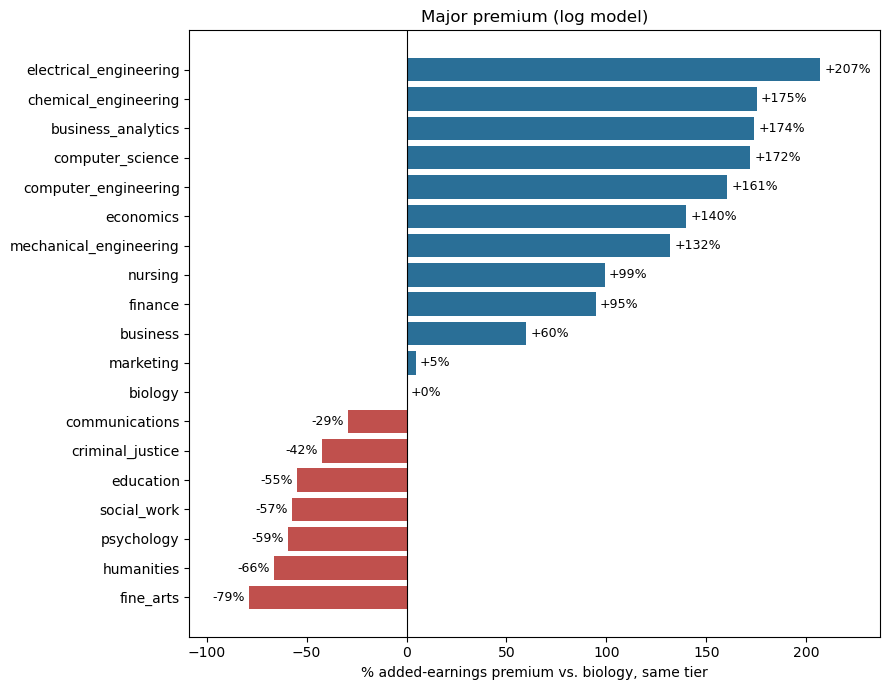

In [49]:
# visualized earnings compared to biology
mp = major_pct.copy()
mp.index = [i.split("T.")[1].rstrip("]") for i in mp.index]
mp.loc["biology"] = 0          # baseline major
mp = mp.sort_values()

colors = ["#c0504d" if v < 0 else "#2a6f97" for v in mp]
fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(mp.index, mp.values, color=colors)
ax.bar_label(bars, fmt="%+.0f%%", fontsize=9, padding=3)
ax.axvline(0, color="black", lw=0.8)

# Pad both ends so the labels on the longest bars fit inside the frame
ax.set_xlim(mp.min() - 30, mp.max() + 30)

ax.set_xlabel("% added-earnings premium vs. biology, same tier")
ax.set_title("Major premium (log model)")
plt.tight_layout()
plt.show()